# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Zhu XueLiang Anson (2500349B)



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [116]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly


# 1. Business Understanding
Goal: The purpose of this project is to develop a machine learning model to predict whether a patient is at risk of getting a heart attack based on their demographic information, medical history, lifestyle habits and clinical measurements.
I chose this topic as heart diseases are one of the leading causes of death worldwide. So, screening and accurately identifying patients with higher risk of heart diseases can help them receive treatment promptly before it is too late.


# 2. Data Understanding

## 2.1 Load dataset

In [117]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "mldp_project_dataset.csv"
df = pd.read_csv(FILE_PATH)

df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
0,40,1,1,140,289,0,0,172,0,0.0,0
1,49,0,2,160,180,0,0,156,0,1.0,1
2,37,1,1,130,283,0,1,98,0,0.0,0
3,48,0,3,138,214,0,0,108,1,1.5,1
4,54,1,2,150,195,0,0,122,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
2938,59,1,1,140,221,0,1,164,1,0.0,1
2939,60,1,0,125,258,0,0,141,1,2.8,0
2940,47,1,0,110,275,0,0,118,1,1.0,0
2941,50,0,0,110,254,0,0,159,0,0.0,1


## 2.2 Summary Statistics

In [118]:
## Understand the type of variable for each column
df.dtypes

Age                 int64
Sex                 int64
ChestPainType       int64
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG          int64
MaxHR               int64
ExerciseAngina      int64
Oldpeak           float64
HeartDisease        int64
dtype: object

In [119]:
## Check for missing data
df.isna().sum() ## Check for missing values


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
HeartDisease      0
dtype: int64

In [120]:
## Describe data distribution
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
count,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000
mean,52.381923,0.748556,1.363575,138.698267,253.515121,0.225280,0.626911,144.040095,0.412504,1.570031,0.548420
std,13.037189,0.433917,1.142614,24.623198,112.724716,0.417838,0.713650,28.446327,0.492369,1.585102,0.497735
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000
25%,44.000000,0.000000,0.000000,120.500000,204.000000,0.000000,0.000000,124.000000,0.000000,0.100000,0.000000
50%,54.000000,1.000000,1.000000,134.000000,248.000000,0.000000,0.000000,145.000000,0.000000,1.200000,1.000000
75%,61.000000,1.000000,2.000000,150.000000,306.000000,0.000000,1.000000,165.000000,1.000000,2.400000,1.000000
max,80.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,1.000000


In [121]:
# Resting BP has min value of 0... something wrong...
# cholesterol has min value of 0... something wrong...

# rest of variables looks correct

In [122]:
print("RestingBP = 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol = 0:", (df["Cholesterol"] == 0).sum())

RestingBP = 0: 1
Cholesterol = 0: 225


In [123]:
#indeed there are patients that have restingbp as 0 which not possible
# wow 225 patients with 0 cholesterol 
# *FIX THOSE WITH MEDIAN*

In [124]:
df["RestingBP"] = df["RestingBP"].replace(0, df["RestingBP"].median())
df["Cholesterol"] = df["Cholesterol"].replace(0, df["Cholesterol"].median())

In [125]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,HeartDisease
count,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000
mean,52.381923,0.748556,1.363575,138.743799,272.475365,0.225280,0.626911,144.040095,0.412504,1.570031,0.548420
std,13.037189,0.433917,1.142614,24.490171,86.222401,0.417838,0.713650,28.446327,0.492369,1.585102,0.497735
min,20.000000,0.000000,0.000000,80.000000,85.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000
25%,44.000000,0.000000,0.000000,121.000000,219.000000,0.000000,0.000000,124.000000,0.000000,0.100000,0.000000
50%,54.000000,1.000000,1.000000,134.000000,248.000000,0.000000,0.000000,145.000000,0.000000,1.200000,1.000000
75%,61.000000,1.000000,2.000000,150.000000,306.000000,0.000000,1.000000,165.000000,1.000000,2.400000,1.000000
max,80.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,1.000000


In [126]:
print("RestingBP = 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol = 0:", (df["Cholesterol"] == 0).sum())

RestingBP = 0: 0
Cholesterol = 0: 0


In [127]:
# ok now the dataset is fine
#fixed with median so values are not influenced by outliers

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

<Axes: xlabel='HeartDisease'>

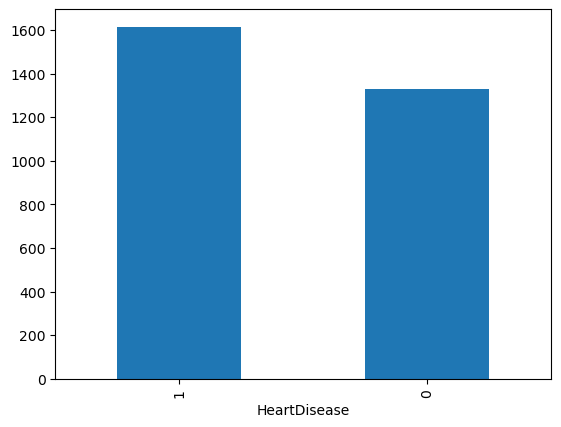

In [128]:
## Understanding distribution of target
col_y = 'HeartDisease'
df[col_y].value_counts().plot(kind='bar')


In [129]:
# target values are more balanced, so less likely to be biased so model can more accurately predict patients with and without heart diseases. 

### 2.3.1.2 Understanding distribution of features

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'MaxHR'}>],
       [<Axes: title={'center': 'Oldpeak'}>, <Axes: >]], dtype=object)

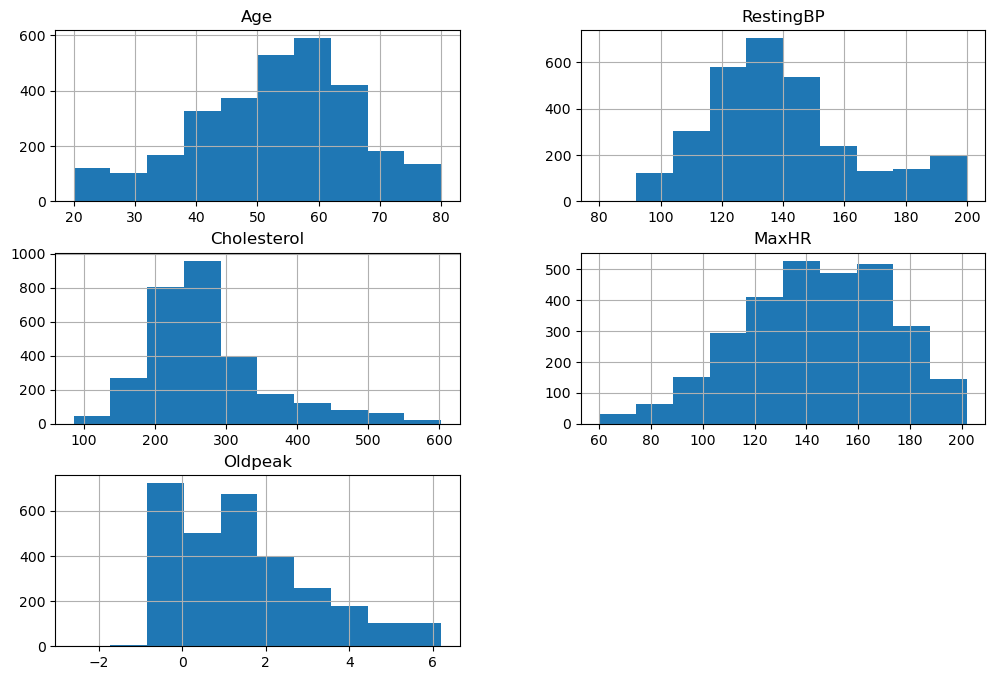

In [130]:
## Understanding distribution of numeric features
numerical = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

df[numerical].hist(figsize=(12,8))

In [131]:
# age almost bell shaped but is mildly left-skewed with the mode being in the late 50s to 60 
# resting bp is almost bell shaped with a mild right skew, with the last bin sticking out slightly
# cholesterol is right-skewed with a very thin tail towars the end and a low value at the front but the majority is in the 200-300 range
# MaxHR is left-skewed with majority of patients withing the 100 to ~170 rangee with a few patients on the extremes of under 100 and over 180
# OldPeak is bi-modal that is right-skewed with a spike at -1 and then at around 1+


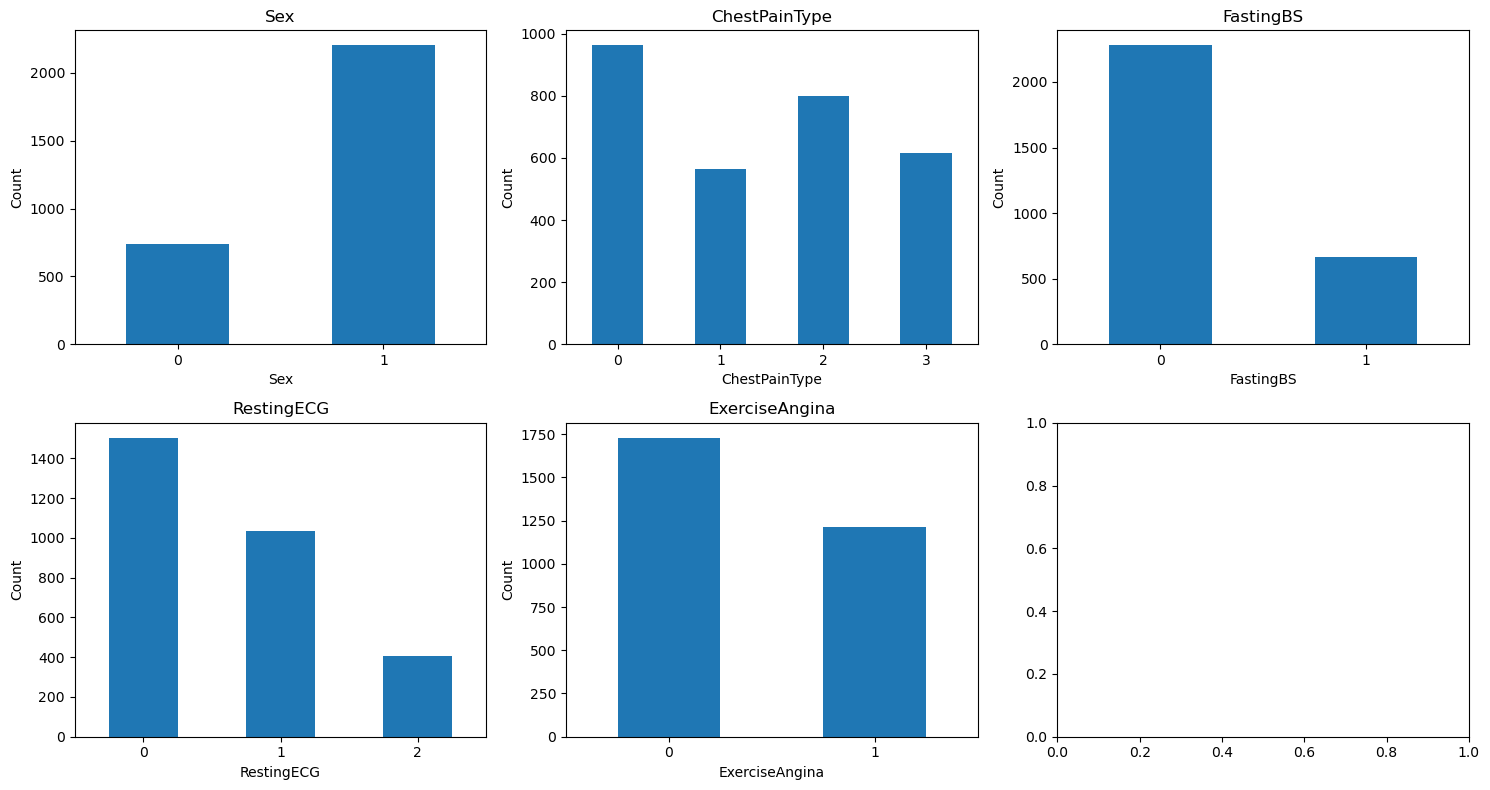

In [132]:
## Understanding distribution of categorical features

categorical = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina', 
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), categorical):  ##pair each feature to a graph
    df[col].value_counts().sort_index().plot(
        kind='bar',
        ax=ax,
        title=col
    )
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', labelrotation=0)

plt.tight_layout()
plt.show()

### 2.3.2 Understanding relationship between variables

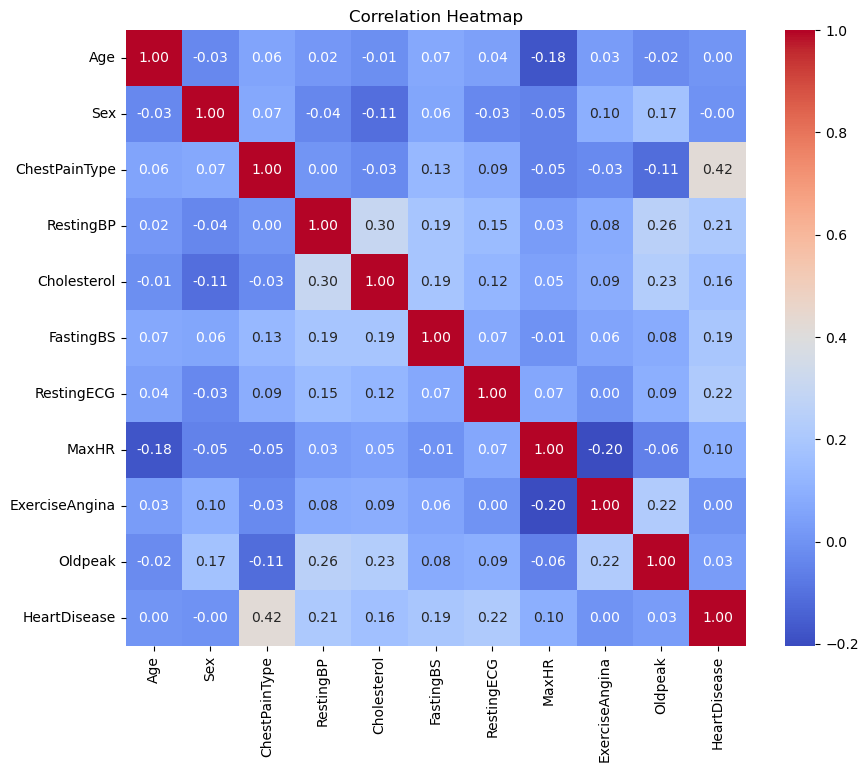

In [133]:
## Understanding relationship between variables
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),  annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [134]:
# ChestPainType has the highest positive correlation with HeartDisease with a value oof 0.42 which means it is moderate positive
# Cholesterol and RestingBP has a weak positive correalation value of 0.3

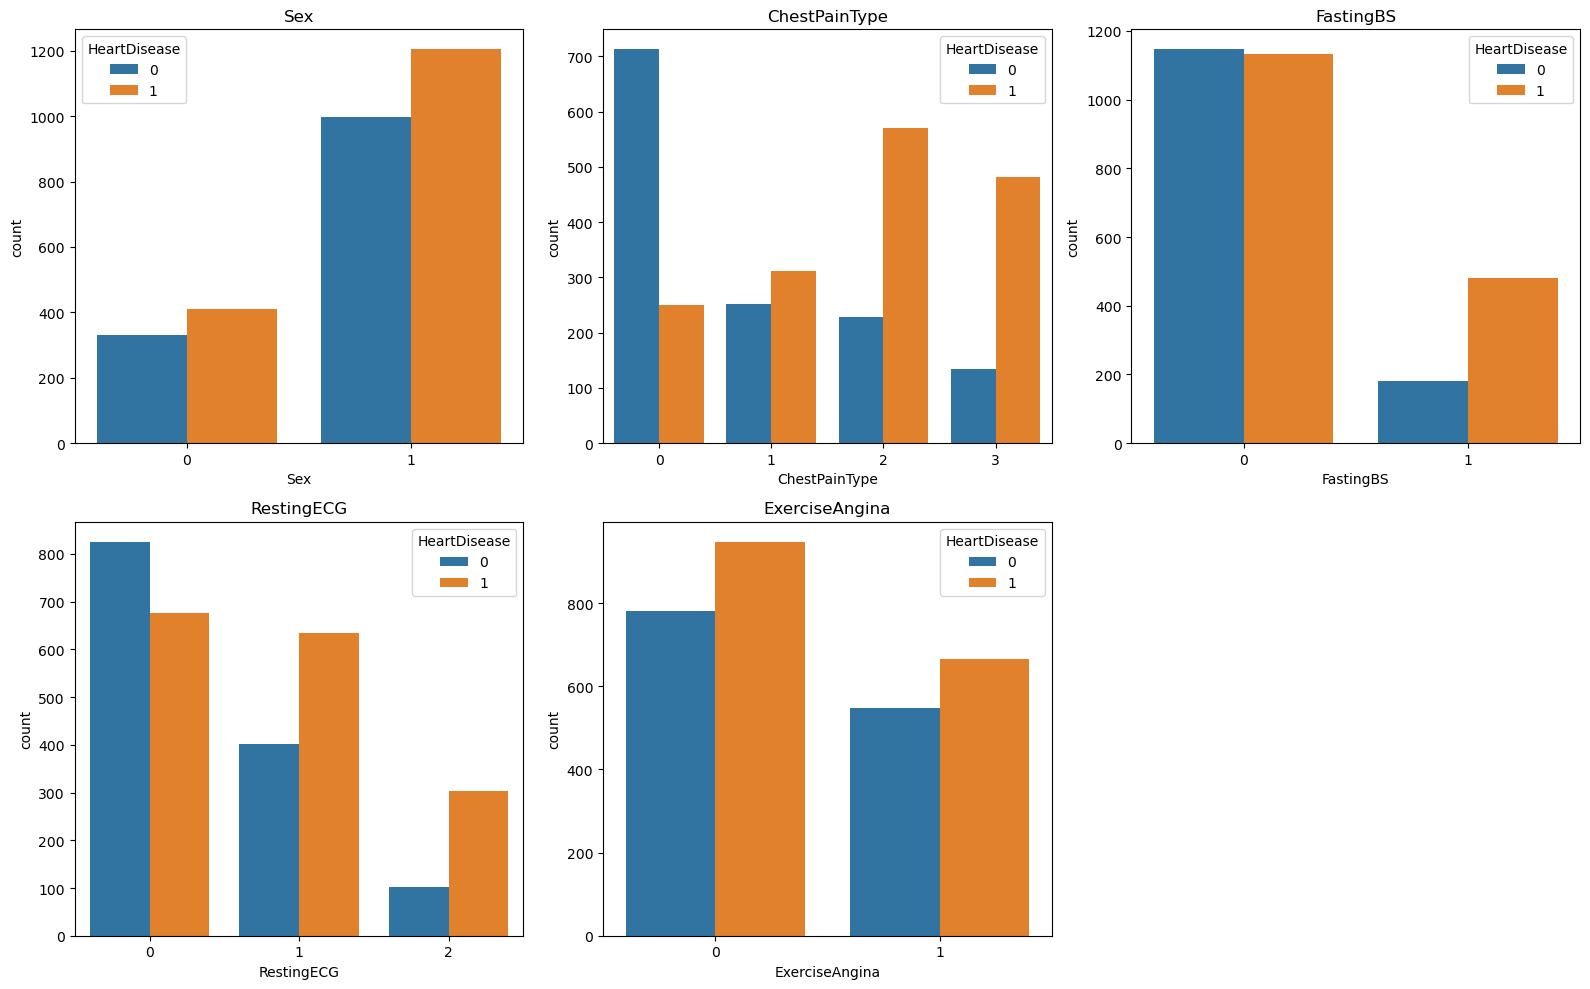

In [135]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical):
    sns.countplot(
        x=feature,
        hue=col_y,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(feature)

# Remove the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [136]:
# there are more males than females
# patients with a chest pain type of 0 has the highest amount of none heart disease patients
# patients with a chest pain type of 1 are evenly balanced out to have or not have heart diseases.
# patients with a chest pain type of 2 and 3 have a higher amount of heart diseases patients in their own catergory type

# resting ecg type 0 has more non heart-diseases than heart diseases
# resting ecg type 1 and 2 have more heart dieases than none heart diseases

# exercise angina have more heart diseases than non heart diseases 

# 3. Data Preparation

## 3.1 Data Cleaning

In [137]:
## Clean data
y = df[col_y]
X = df.drop(col_y, axis = 1)

X

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak
0,40,1,1,140,289,0,0,172,0,0.0
1,49,0,2,160,180,0,0,156,0,1.0
2,37,1,1,130,283,0,1,98,0,0.0
3,48,0,3,138,214,0,0,108,1,1.5
4,54,1,2,150,195,0,0,122,0,0.0
...,...,...,...,...,...,...,...,...,...,...
2938,59,1,1,140,221,0,1,164,1,0.0
2939,60,1,0,125,258,0,0,141,1,2.8
2940,47,1,0,110,275,0,0,118,1,1.0
2941,50,0,0,110,254,0,0,159,0,0.0


## 3.2 Train-Test Split

In [138]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=690
)



# 4. Modelling

### 4.2 Train Model

In [139]:
## Initialise and train model


from sklearn.linear_model import LogisticRegression
## Initialise model
logr = LogisticRegression(max_iter=200) ## Logistic Regression model
logr.fit(X_train, y_train) ## Train model




c:\Users\bedro\anaconda3\Phyton\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [140]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

gbt = GradientBoostingClassifier(random_state=690)

rf = RandomForestClassifier( n_estimators = 100 ,random_state=690)

dt = DecisionTreeClassifier(random_state=690)

from sklearn.metrics import accuracy_score

y_pred_logr = logr.predict(X_test)
gbt.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

y_pred_gbt = gbt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_dt = dt.predict(X_test)


# 5. Model Evaluation

In [141]:
from sklearn.metrics import confusion_matrix

results = []

models = {
    "Logistic Regression": y_pred_logr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbt
}

for model_name, y_pred in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Model": model_name,
        
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

results_df = pd.DataFrame(results)

results_df

,Model,TP,TN,FP,FN
0,Logistic Regression,384,280,107,112
1,Decision Tree,416,299,88,80
2,Random Forest,443,325,62,53
3,Gradient Boosting,406,297,90,90


In [142]:
## Random Forest achieved the highest number of True Positives (TP = 443), showing that it correctly identified the greatest number of patients with heart disease.
## Random Forest achieved the highest number of True Negatives (TN = 325), showing that it correctly identified the greatest number of patients without heart disease.
## Random Forest produced the lowest number of False Positives (FP = 62), showing that it incorrectly classified the fewest healthy patients as having heart disease.
## Random Forest produced the lowest number of False Negatives (FN = 53), showing that it incorrectly classified the fewest patients with heart disease as healthy.

In [143]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": y_pred_logr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbt
}

for model_name, y_pred in models.items():
    

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
      

    })

results_df = pd.DataFrame(results)

results_df = results_df.round(3)

results_df



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.752,0.782,0.774,0.778
1,Decision Tree,0.810,0.825,0.839,0.832
2,Random Forest,0.870,0.877,0.893,0.885
3,Gradient Boosting,0.796,0.819,0.819,0.819


In [144]:
# # Logistic Regression achieved the lowest overall performance, with an accuracy of 75.2%, precision of 78.2%, recall of 77.4%, and F1-score of 77.8%. 
# As the baseline model, it provides a useful benchmark but was outperformed by the tree-based models.

# # Decision Tree showed a significant improvement over Logistic Regression, achieving an accuracy of 81.0% and a recall of 83.9%. 
# This indicates that the model was better at correctly identifying patients with heart disease while maintaining good overall classification performance.

# # Random Forest achieved the highest performance across all evaluation metrics, with an accuracy of 87.0%, precision of 87.7%, recall of 89.3%, and F1-score of 88.5%. 
# The high recall indicates that the model successfully identified the largest proportion of patients with heart disease, 
# while the high precision means that most patients predicted to have heart disease were correctly classified. 
# The high F1-score demonstrates a strong balance between precision and recall.

# # Gradient Boosting performed better than Logistic Regression but was less effective than both Decision Tree and Random Forest.
#  Although it achieved reasonably good accuracy (79.6%) and F1-score (81.9%), it produced lower precision and recall than Random Forest.

# USE RANDOM FOREST

## Iterative model development


In [145]:
## Further feature engineering / feature selection

df_dt_feat_impt = pd.DataFrame({
                                'Feature': rf.feature_names_in_,                               
                                'Importance':rf.feature_importances_
})

df_dt_feat_impt['Feature'] = df_dt_feat_impt['Feature'].str.rsplit('_',n=1).str[0]
df_dt_feat_impt = df_dt_feat_impt.groupby('Feature')['Importance'].sum().sort_values(ascending = False).reset_index()

df_dt_feat_impt['Cumalative importance'] = df_dt_feat_impt['Importance'].cumsum()

df_dt_feat_impt

,Feature,Importance,Cumalative importance
0,ChestPainType,0.189507,0.189507
1,Cholesterol,0.160864,0.350371
2,MaxHR,0.140404,0.490775
3,RestingBP,0.130626,0.621401
4,Oldpeak,0.106562,0.727963
5,Age,0.106198,0.834161
6,RestingECG,0.072774,0.906935
7,ExerciseAngina,0.036602,0.943537
8,Sex,0.029067,0.972604
9,FastingBS,0.027396,1.000000


In [146]:
# ChestPainType is the most influential feature in predicting whether a patient has heart diseases with an importance score of 0.189 which approx 19% of the total feature importance
# it is then followed by cholesterol and max heart rate with an importance score of 0.16 and 0.14 respectively 
# these 3 features make up for almost 50% of the feature importance for the model_name

# the 3 least influential features are exercise angina, sex and fasting bs which have an importance socre of 0.036, 0.029 and 0.027 respectively
# these 3 features make up for about 9.3% of the feature importance.
 






C:\Users\bedro\AppData\Local\Temp\ipykernel_2592\4175856005.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_dt_feat_impt['Feature'], rotation=45, ha='right')


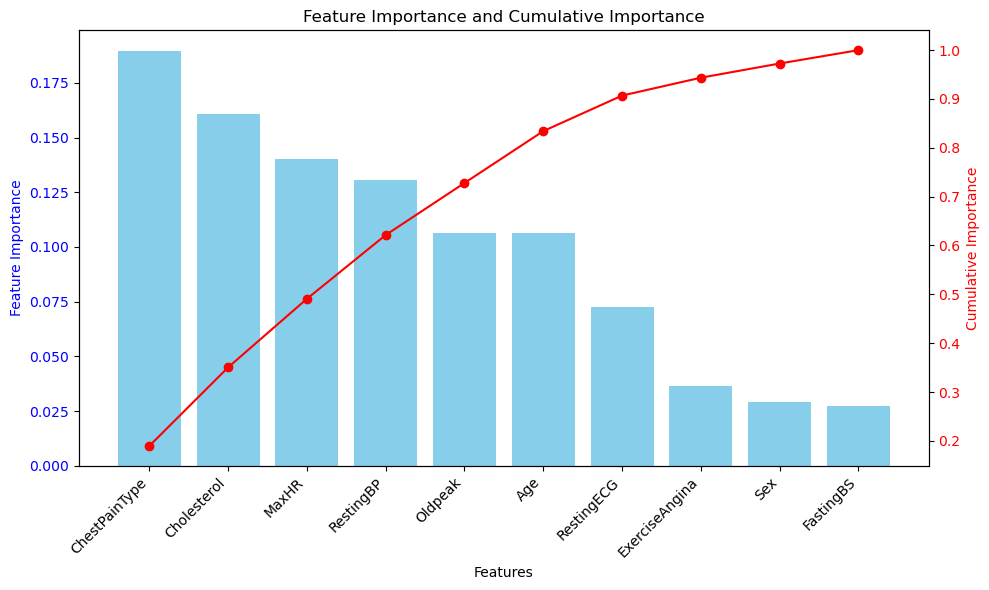

In [147]:
## Plot feature importance and cumulative importance
fig, ax1 = plt.subplots(figsize=(10, 6))
 
# Bar chart for feature importance
ax1.bar(df_dt_feat_impt['Feature'], df_dt_feat_impt['Importance'], color='skyblue')
ax1.set_xlabel('Features')
ax1.set_ylabel('Feature Importance', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(df_dt_feat_impt['Feature'], rotation=45, ha='right')
 
# Line chart for cumulative importance
ax2 = ax1.twinx()
# in the previous cell
df_dt_feat_impt['Cumulative importance'] = df_dt_feat_impt['Importance'].cumsum()

# in cell 36
ax2.plot(df_dt_feat_impt['Feature'], df_dt_feat_impt['Cumulative importance'], color='red', marker='o')
ax2.set_ylabel('Cumulative Importance', color='red')
ax2.tick_params(axis='y', labelcolor='red')
 
plt.title('Feature Importance and Cumulative Importance')
plt.tight_layout()
plt.show()

In [148]:
# this graph supports the table as a visual aid to better understand the feature importance of the various features.

In [149]:
#doing feature selection

In [150]:
col_y = 'HeartDisease'

In [151]:
y_fs = df[col_y]

#re-establish the target value
#naming everything with a fs to identify it is for feature selection

In [152]:
#dropping target value, and also the 3 features that had less than 10% of feature importance
#not dropping resting ecg as it pushes the overall feature importance pass 90% and that is the threshold that i am using.

col_drop = [col_y,"FastingBS","Sex","ExerciseAngina"]
X_fs = df.drop(col_drop, axis = 1)
X_fs

,Age,ChestPainType,RestingBP,Cholesterol,RestingECG,MaxHR,Oldpeak
0,40,1,140,289,0,172,0.0
1,49,2,160,180,0,156,1.0
2,37,1,130,283,1,98,0.0
3,48,3,138,214,0,108,1.5
4,54,2,150,195,0,122,0.0
...,...,...,...,...,...,...,...
2938,59,1,140,221,1,164,0.0
2939,60,0,125,258,0,141,2.8
2940,47,0,110,275,0,118,1.0
2941,50,0,110,254,0,159,0.0


In [153]:
#re-training anohter RF Model

from sklearn.model_selection import train_test_split

X_fs_train, X_fs_test, y_fs_train, y_fs_test = train_test_split(
   X_fs, y_fs,
   test_size=0.3,
    random_state=690
)


In [154]:
#using RF as seen from and decided above.


from sklearn.ensemble import RandomForestClassifier

rf_fs = RandomForestClassifier(n_estimators=100, random_state=690)

rf_fs.fit(X_fs_train, y_fs_train)

y_pred_rf_fs = rf_fs.predict(X_fs_test)

In [155]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_df_fs = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_fs_test, y_pred_rf_fs)],
    "Precision": [precision_score(y_fs_test, y_pred_rf_fs)],
    "Recall": [recall_score(y_fs_test, y_pred_rf_fs)],
    "F1-score": [f1_score(y_fs_test, y_pred_rf_fs)]
}).round(3)

results_df_fs



,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.874,0.872,0.909,0.89


In [156]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Original RF": [
        results_df.loc[results_df["Model"] == "Random Forest", "Accuracy"].values[0],
        results_df.loc[results_df["Model"] == "Random Forest", "Precision"].values[0],
        results_df.loc[results_df["Model"] == "Random Forest", "Recall"].values[0],
        results_df.loc[results_df["Model"] == "Random Forest", "F1-score"].values[0]
    ],
    "Feature Selected RF": [
        results_df_fs.loc[0, "Accuracy"],
        results_df_fs.loc[0, "Precision"],
        results_df_fs.loc[0, "Recall"],
        results_df_fs.loc[0, "F1-score"]
    ]
})

comparison_df

,Metric,Original RF,Feature Selected RF
0,Accuracy,0.870,0.874
1,Precision,0.877,0.872
2,Recall,0.893,0.909
3,F1-score,0.885,0.890


In [157]:
# after removing the 3 least influential features (FastingBS, Sex & ExerciseAngina)
# the accuracy of the feature selection RF model increased from 0.870 of the original to 0.874
#so it has correctly pridicted more TP & TN values

# the percision saw a slight decrease from 0.877 to 0.872

# both recall and f1-score saw an increase 
#recall gaining a lot from 0.893 to 0.909 
#while f1-score saw in increase from 0.885 to 0.890

#overall, the feature selection model performed better than the original model 

#use rf_fs model

In [158]:
import joblib
joblib.dump(rf_fs, 'mldp_project_model.pkl')

['mldp_project_model.pkl']